<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_07_Aluno_Estrutura_CNN_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 7 – Estrutura de CNN

## Versão do Aluno

### Capacidades
- Aplicar visão computacional.

### Conhecimentos
- Convolução.
- Camadas convolucionais.
- Pooling.
- Flatten.
- Mapas de ativação.
- Classificação de imagens.

### Evidência de aprendizagem
CNN funcional em notebook.

# 1. Contextualização

Nesta aula, vamos estudar CNN, uma arquitetura muito usada em visão computacional.

Complete:

CNN significa Convolutional Neural Network (Rede Neural Convolucional.

Na indústria, uma CNN pode ser usada para:

- inspeção de qualidade e detecção de defeitos em produtos;
- classificação automática de peças ou objetos;
- identificação e reconhecimento de padrões em imagens industriais.

# 2. Conceitos fundamentais

Complete:

## Convolução
A convolução aplica pequenos filtros (ou kernels) sobre a imagem para extrair características.

## Camada convolucional
No Keras, a camada convolucional é criada com Conv2D.

## Pooling
O pooling serve para reduzir  a dimensão espacial dos mapas de características.

## Flatten
A camada Flatten transforma os mapas de características em um vetor unidimensional..

In [1]:
# Célula 1 - Bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 3. Carregamento do CIFAR-10

Complete:

O CIFAR-10 possui imagens de 32 x 32 pixels.

Cada imagem possui 3 canais de cor.

O dataset possui 10 classes.

In [2]:
# Célula 2 - Dataset

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

classes = ["avião", "automóvel", "pássaro", "gato", "cervo",
           "cachorro", "sapo", "cavalo", "navio", "caminhão"]

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
x_train: (50000, 32, 32, 3)
y_train: (50000, 1)
x_test: (10000, 32, 32, 3)
y_test: (10000, 1)


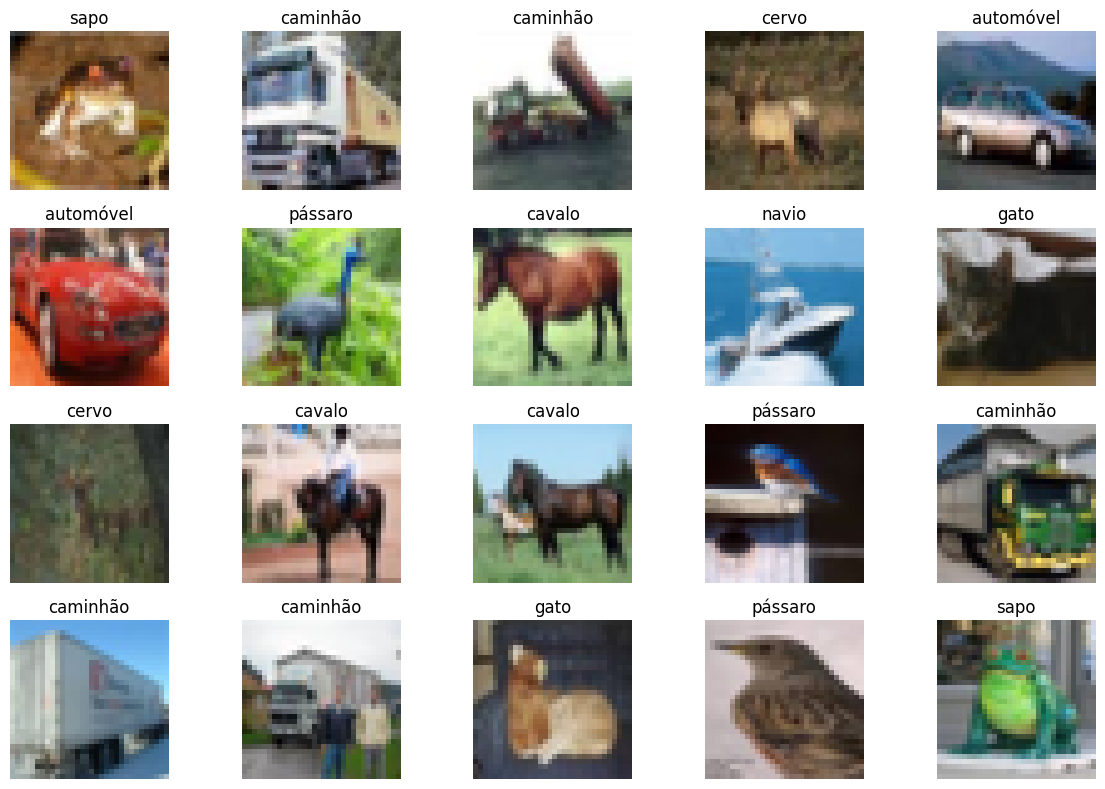

In [3]:
# Célula 3 - Visualização das imagens

plt.figure(figsize=(12, 8))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_train[i])
    plt.title(classes[int(y_train[i][0])])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 4. Normalização

Complete:

Os pixels variam de 0 a 255.

Para normalizar, dividimos por 255.

In [4]:
# Célula 4 - Normalização e subconjunto didático

x_train_norm = x_train.astype("float32") / 255
x_test_norm = x_test.astype("float32") / 255

x_train_small = x_train_norm[:10000]
y_train_small = y_train[:10000]
x_test_small = x_test_norm[:2000]
y_test_small = y_test[:2000]

print("Treino:", x_train_small.shape)
print("Teste:", x_test_small.shape)

Treino: (10000, 32, 32, 3)
Teste: (2000, 32, 32, 3)


# 5. Demonstração didática do Max Pooling

Complete:

O Max Pooling seleciona o valor máximo dentro de uma região.

Matriz original:
[[1 3 2 4]
 [5 6 1 2]
 [7 2 9 3]
 [1 4 2 8]]

Após Max Pooling 2x2:
[[6 4]
 [7 9]]


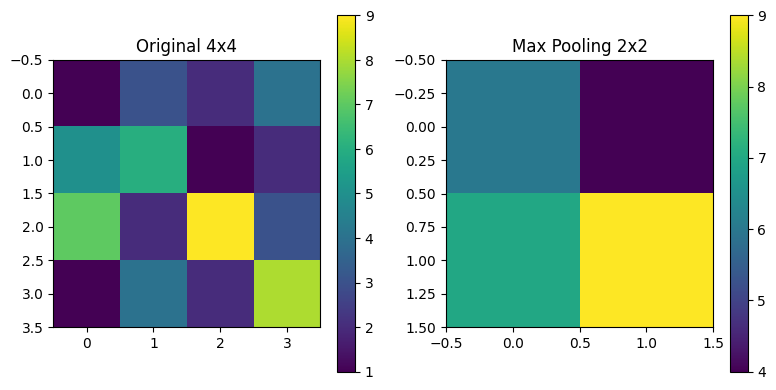

In [5]:
# Célula 5 - Max Pooling manual

matriz = np.array([
    [1, 3, 2, 4],
    [5, 6, 1, 2],
    [7, 2, 9, 3],
    [1, 4, 2, 8]
])

pooling = np.array([
    [np.max(matriz[0:2, 0:2]), np.max(matriz[0:2, 2:4])],
    [np.max(matriz[2:4, 0:2]), np.max(matriz[2:4, 2:4])]
])

print("Matriz original:")
print(matriz)

print("\nApós Max Pooling 2x2:")
print(pooling)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(matriz, cmap="viridis")
plt.title("Original 4x4")
plt.colorbar()

plt.subplot(1,2,2)
plt.imshow(pooling, cmap="viridis")
plt.title("Max Pooling 2x2")
plt.colorbar()

plt.tight_layout()
plt.show()

# 6. Construção da CNN

Complete a arquitetura.

In [6]:
# Modelo CNN
modelo_cnn = models.Sequential([
layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3),
name="conv_1"),
layers.MaxPooling2D((2, 2), name="pool_1"),
layers.Conv2D(64, (3, 3), activation="relu", name="conv_2"),
layers.MaxPooling2D((2, 2), name="pool_2"),
layers.Flatten(name="flatten"),
layers.Dense(64, activation="relu", name="dense_intermediaria"),
layers.Dense(10, activation="softmax", name="saida")
])
modelo_cnn.compile(
optimizer="sgd",
loss="sparse_categorical_crossentropy",
metrics=["accuracy"]
)
modelo_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv_1 (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_1 (MaxPooling2D)           │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool_2 (MaxPooling2D)           │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_intermediaria (Dense)     │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ saida (Dense)                   │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

# 7. Interpretação da arquitetura

Responda após observar o summary:

1. Qual camada extrai características da imagem?
A camada que extrai características da imagem é a camada convolucional (Conv2D).

2. Qual camada reduz a dimensão espacial?
opilotA camada que reduz a dimensão espacial é a camada de pooling (ex: MaxPooling2D).

3. Qual camada transforma os mapas em vetor?
A camada que transforma os mapas em vetor é a camada Flatten.

4. Qual camada gera a classificação final?
A camada que gera a classificação final é a camada densa (Dense), geralmente com função de ativação Softmax.

In [7]:
# Célula 7 - Treinamento

historico = modelo_cnn.fit(
    x_train_small,
    y_train_small,
    epochs=11,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.1326 - loss: 2.2942 - val_accuracy: 0.1405 - val_loss: 2.2826
Epoch 2/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 84ms/step - accuracy: 0.1716 - loss: 2.2663 - val_accuracy: 0.1955 - val_loss: 2.2437
Epoch 3/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 78ms/step - accuracy: 0.2132 - loss: 2.2000 - val_accuracy: 0.2290 - val_loss: 2.1537
Epoch 4/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - accuracy: 0.2424 - loss: 2.0922 - val_accuracy: 0.2480 - val_loss: 2.0543
Epoch 5/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - accuracy: 0.2665 - loss: 2.0128 - val_accuracy: 0.2545 - val_loss: 2.0102
Epoch 6/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 20s 83ms/step - accuracy: 0.2804 - loss: 1.9776 - val_accuracy: 0.2805 - val_loss: 1.9769
Epoch 7/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 9s 72ms/step - accuracy: 0.2944 - loss: 1.9436 - val_accuracy: 0.3015 - val_loss: 1.9546
Epoch 8/11
125/125 ━━━━━━━━━━━━━━━━━━━━ 10s 83ms/step - accuracy: 0.3054 - loss: 1.9127 - v

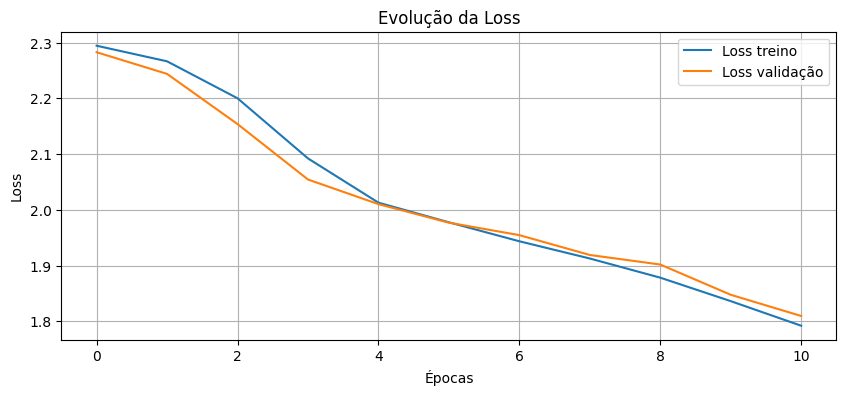

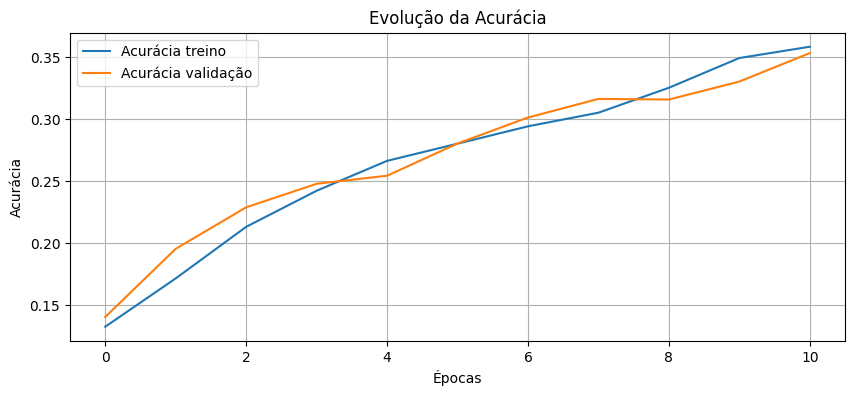

In [8]:
# Célula 8 - Curvas de treinamento

plt.figure(figsize=(10,4))
plt.plot(historico.history["loss"], label="Loss treino")
plt.plot(historico.history["val_loss"], label="Loss validação")
plt.title("Evolução da Loss")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10,4))
plt.plot(historico.history["accuracy"], label="Acurácia treino")
plt.plot(historico.history["val_accuracy"], label="Acurácia validação")
plt.title("Evolução da Acurácia")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# Célula 9 - Avaliação

loss_teste, acc_teste = modelo_cnn.evaluate(x_test_small, y_test_small, verbose=0)

print(f"Loss no teste: {loss_teste:.4f}")
print(f"Acurácia no teste: {acc_teste:.4f}")

Loss no teste: 1.8051
Acurácia no teste: 0.3705


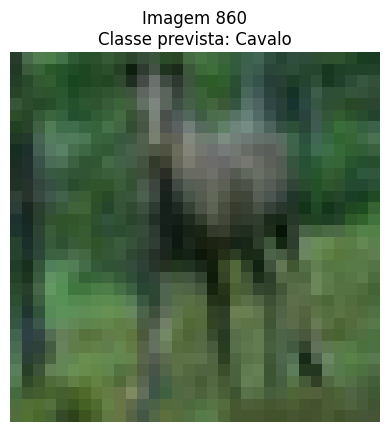

7


In [22]:
import numpy as np
import matplotlib.pyplot as plt

classes = [
    "Avião", "Automóvel", "Pássaro", "Gato", "Veado",
    "Cachorro", "Sapo", "Cavalo", "Navio", "Caminhão"
]

np.random.seed(42)

img_sort = np.random.randint(0, 5000)

predicoe_sort = modelo_cnn.predict(
    x_test_small[img_sort:img_sort+1],
    verbose=0
)

classe_prevista = np.argmax(predicoe_sort, axis=1)[0]

plt.imshow(x_test_small[img_sort])
plt.title(
    f"Imagem {img_sort}\n"
    f"Classe prevista: {classes[classe_prevista]}"
)
plt.axis("off")
plt.show()

# plt.imshow(x_test_small[predicoe_sort)
# plt.axis('off')

predicoe_sort
print(np.argmax(predicoe_sort, axis=1)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


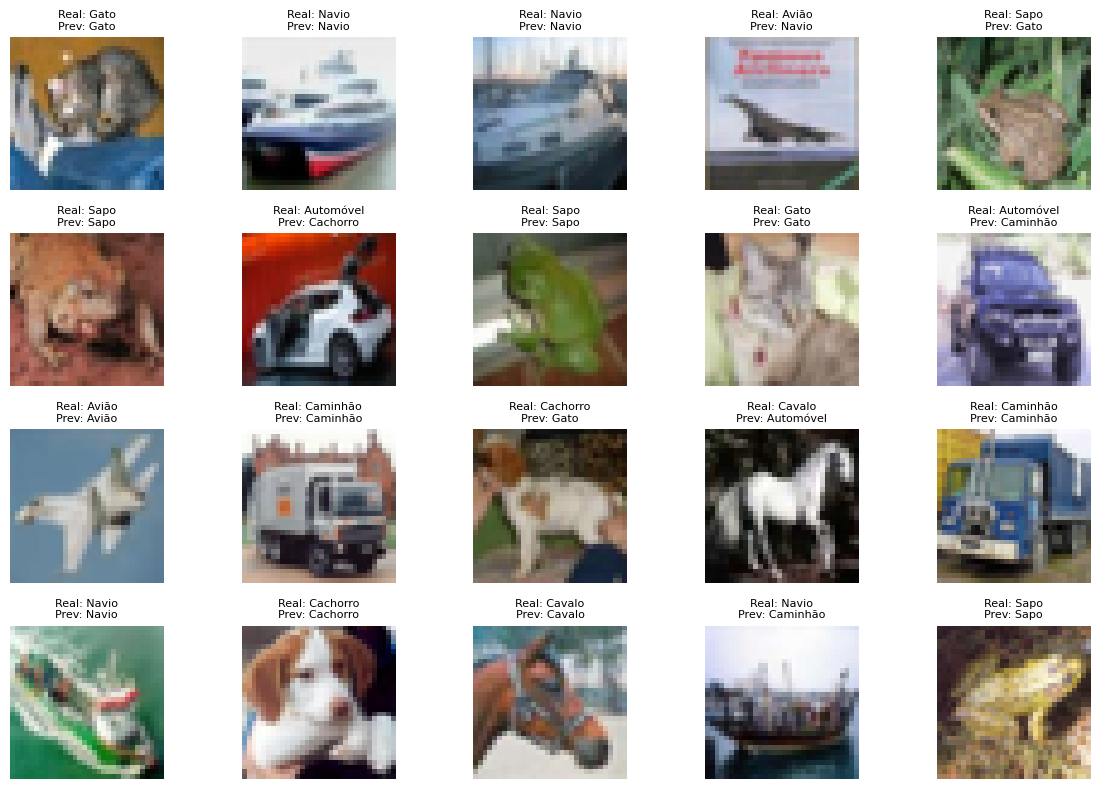

In [23]:
# Célula 10 - Predições

predicoes = modelo_cnn.predict(x_test_small[:20])
classes_previstas = np.argmax(predicoes, axis=1)

plt.figure(figsize=(12, 8))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(x_test[i])
    real = int(y_test_small[i][0])
    previsto = int(classes_previstas[i])
    plt.title(f"Real: {classes[real]}\nPrev: {classes[previsto]}", fontsize=8)
    plt.axis("off")
plt.tight_layout()
plt.show()

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


<Figure size 1000x1000 with 0 Axes>

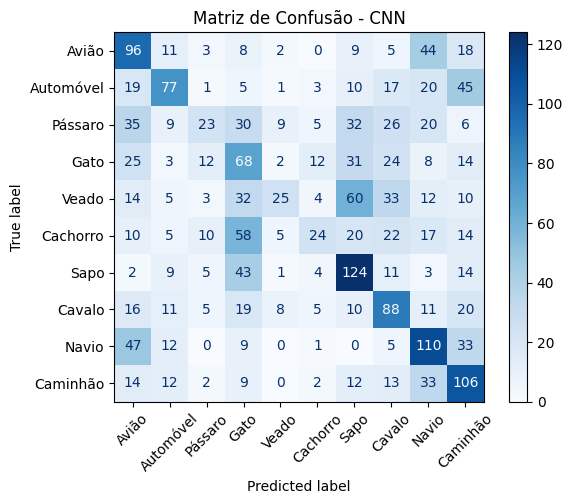

              precision    recall  f1-score   support

       Avião       0.35      0.49      0.41       196
   Automóvel       0.50      0.39      0.44       198
     Pássaro       0.36      0.12      0.18       195
        Gato       0.24      0.34      0.28       199
       Veado       0.47      0.13      0.20       198
    Cachorro       0.40      0.13      0.20       185
        Sapo       0.40      0.57      0.47       216
      Cavalo       0.36      0.46      0.40       193
       Navio       0.40      0.51      0.44       217
    Caminhão       0.38      0.52      0.44       203

    accuracy                           0.37      2000
   macro avg       0.39      0.37      0.35      2000
weighted avg       0.39      0.37      0.35      2000



In [24]:
# Célula 11 - Matriz de confusão

pred_test = modelo_cnn.predict(x_test_small)
y_pred = np.argmax(pred_test, axis=1)
y_true = y_test_small.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(xticks_rotation=45, cmap="Blues", values_format="d")
plt.title("Matriz de Confusão - CNN")
plt.show()

print(classification_report(y_true, y_pred, target_names=classes))

# 8. Mapas de ativação

Complete:

Os mapas de ativação mostram como os neurônios (ou filtros) da CNN respondem à imagem.

Eles ajudam a visualizar padrões aprendidos, como _bordas, texturas e formas/objetos.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


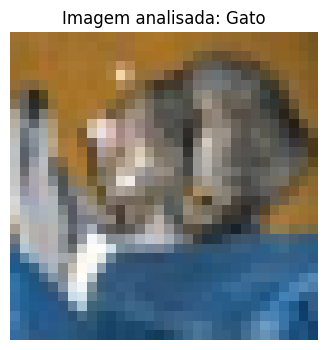

conv_1 (1, 30, 30, 32)
pool_1 (1, 15, 15, 32)
conv_2 (1, 13, 13, 64)
pool_2 (1, 6, 6, 64)


In [25]:
# Célula 12 - Modelo intermediário para mapas de ativação

imagem_exemplo = x_test_small[0:1]
nomes_camadas = ["conv_1", "pool_1", "conv_2", "pool_2"]

saidas = [modelo_cnn.get_layer(nome).output for nome in nomes_camadas]

modelo_ativacoes = tf.keras.Model(
    inputs=modelo_cnn.inputs,
    outputs=saidas
)

ativacoes = modelo_ativacoes.predict(imagem_exemplo)

plt.figure(figsize=(4,4))
plt.imshow(x_test[0])
plt.title(f"Imagem analisada: {classes[int(y_test_small[0][0])]}")
plt.axis("off")
plt.show()

for nome, ativacao in zip(nomes_camadas, ativacoes):
    print(nome, ativacao.shape)

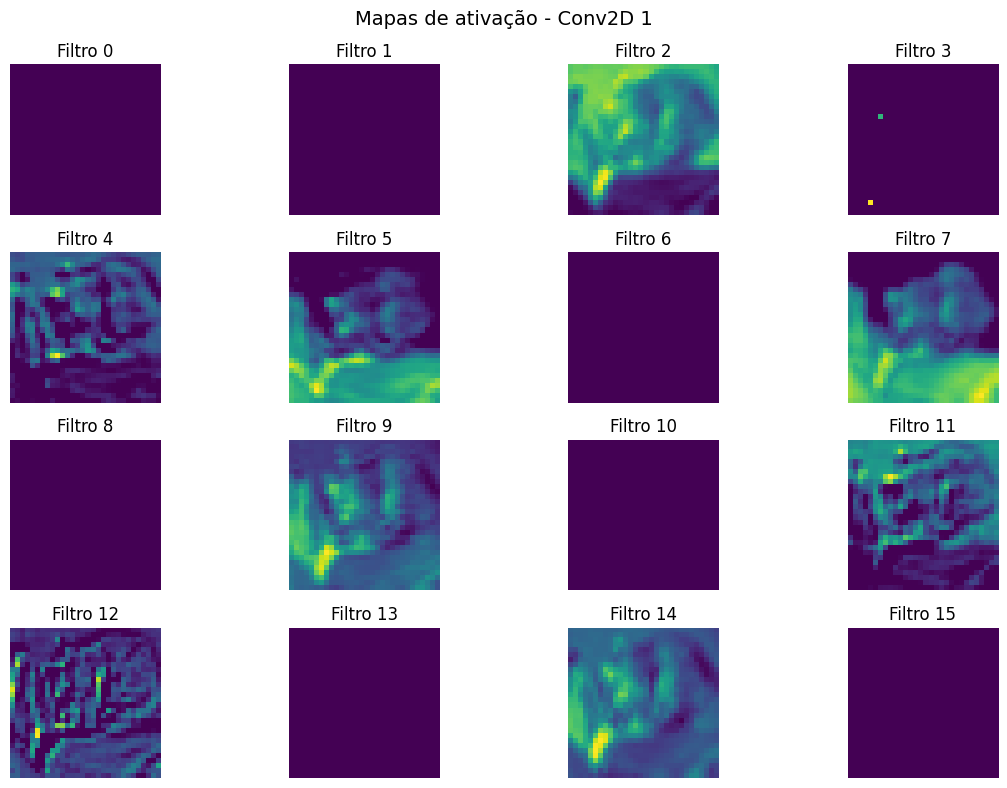

In [26]:
# Célula 13 - Mapas de ativação da primeira convolução

ativacao_conv1 = ativacoes[0]
num_mapas = 16

plt.figure(figsize=(12, 8))
for i in range(num_mapas):
    plt.subplot(4, 4, i+1)
    plt.imshow(ativacao_conv1[0, :, :, i], cmap="viridis")
    plt.title(f"Filtro {i}")
    plt.axis("off")

plt.suptitle("Mapas de ativação - Conv2D 1", fontsize=14)
plt.tight_layout()
plt.show()

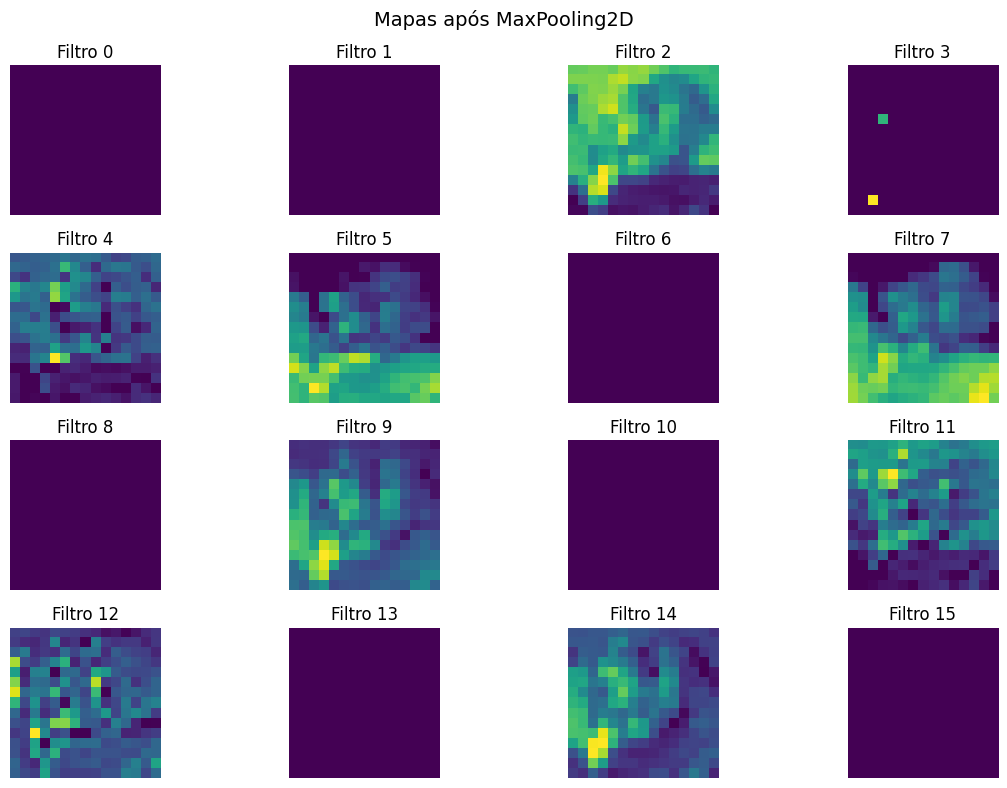

In [27]:
# Célula 14 - Mapas após pooling

ativacao_pool1 = ativacoes[1]

plt.figure(figsize=(12, 8))
for i in range(num_mapas):
    plt.subplot(4, 4, i+1)
    plt.imshow(ativacao_pool1[0, :, :, i], cmap="viridis")
    plt.title(f"Filtro {i}")
    plt.axis("off")

plt.suptitle("Mapas após MaxPooling2D", fontsize=14)
plt.tight_layout()
plt.show()

# 9. Atividade avaliativa

Responda:

1. O que é convolução?
Convolução é uma operação matemática que aplica filtros (kernels) sobre a imagem para extrair características importantes, como bordas, texturas e padrões.
Em uma CNN, a convolução percorre a imagem realizando cálculos em pequenas regiões, gerando mapas de características (feature maps).

2. Qual a função da camada Conv2D?
A camada `Conv2D` (Camada Convolucional 2D) é responsável por aplicar filtros convolucionais à imagem de entrada, criando mapas de características que destacam padrões importantes como bordas, texturas e formas. Ela é o coração da extração de características em uma CNN.

3. Qual a função do MaxPooling2D?
A função da camada `MaxPooling2D` é reduzir a dimensionalidade espacial dos mapas de características (feature maps) produzidos pelas camadas convolucionais. Isso é feito selecionando o valor máximo de cada sub-região (janela de pooling), o que ajuda a tornar o modelo mais robusto a pequenas variações e a reduzir a quantidade de parâmetros e o custo computacional.

4. Qual a função da camada Flatten?
A camada `Flatten` transforma a entrada multidimensional (os mapas de características após as camadas convolucionais e de pooling) em um vetor unidimensional. Essa operação é necessária para conectar as camadas convolucionais/de pooling com as camadas totalmente conectadas (Dense) subsequentes, que esperam uma entrada linear.

5. Por que CNNs são mais adequadas para imagens do que redes densas simples?
CNNs são mais adequadas para imagens do que redes densas simples por várias razões:
*   **Consciência Espacial:** Elas preservam a estrutura espacial da imagem, ao contrário das redes densas que linearizam a entrada, perdendo informações de localização.
*   **Compartilhamento de Pesos:** Os filtros convolucionais são aplicados em toda a imagem, o que significa que os mesmos pesos são usados para detectar a mesma característica em diferentes locais, reduzindo drasticamente o número de parâmetros e melhorando a generalização.
*   **Invariância a Translações:** Devido ao compartilhamento de pesos e ao pooling, as CNNs são naturalmente mais robustas a pequenas translações e distorções na imagem.
*   **Hierarquia de Características:** Elas aprendem características hierárquicas, começando com padrões simples (bordas) e construindo características mais complexas (partes de objetos, objetos inteiros) em camadas mais profundas.

6. O que representam os mapas de ativação?
Os mapas de ativação (ou feature maps) representam a resposta de um filtro específico de uma camada convolucional a diferentes regiões da imagem de entrada. Eles mostram quais padrões ou características o filtro detectou na imagem. Em camadas mais iniciais, podem mostrar bordas ou texturas simples, enquanto em camadas mais profundas, podem indicar a presença de partes de objetos ou características mais complexas.

7. Como a matriz de confusão ajuda na avaliação de uma CNN?
A matriz de confusão é uma ferramenta valiosa para avaliar o desempenho de uma CNN em tarefas de classificação. Ela mostra o número de previsões corretas e incorretas feitas pelo modelo para cada classe. A partir dela, podemos calcular métricas como:
*   **Acurácia:** Proporção total de previsões corretas.
*   **Precisão:** Dos itens classificados como uma classe, quantos realmente pertencem a essa classe.
*   **Recall (Sensibilidade):** Dos itens que realmente pertencem a uma classe, quantos foram corretamente classificados.
*   **F1-Score:** Média harmônica entre precisão e recall.
Ela ajuda a identificar quais classes estão sendo bem classificadas e quais classes o modelo está confundindo (erros de classificação).

8. Como essa estrutura poderia ser aplicada em inspeção visual industrial?
Em inspeção visual industrial, uma estrutura de CNN como esta poderia ser aplicada para:
*   **Detecção de Defeitos:** Treinar a CNN para identificar imperfeições em produtos (rachaduras, arranhões, descoloração, etc.) em linhas de produção, garantindo controle de qualidade.
*   **Classificação de Componentes:** Automatizar a classificação e triagem de peças ou componentes com base em suas características visuais.
*   **Contagem de Itens:** Contar o número de produtos em uma embalagem ou em uma área específica.
*   **Verificação de Montagem:** Assegurar que todos os componentes necessários estejam presentes e corretamente posicionados em um produto montado.
*   **Identificação de Segurança:** Reconhecer equipamentos de proteção individual (EPIs) em funcionários ou identificar áreas restritas.
*   **Monitoramento de Processos:** Analisar imagens de processos de fabricação para detectar anomalias ou otimizar parâmetros.